In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from joblib import load
from tqdm import tqdm
import warnings

from sklearn.metrics import classification_report
warnings.filterwarnings("ignore")
import glob
import os
from collections import OrderedDict
from src.layers.classifiers import TokenClassifier, MixedClassifier

import h5py
import sys

import numpy as np
import matplotlib.pyplot as plt 
from matplotlib import cm


In [4]:

path = '/home/mdelafuente/'#sys.argv[2]

 
abs_path = '/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/ZTF_ff/LC_MD/MM_bothmultiple48v2_/'
path_args = glob.glob(f"{abs_path}*args*")[0]
print(path_args)
import yaml
with open(path_args, 'r') as file:
    args = yaml.safe_load(file)

/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/ZTF_ff/LC_MD/MM_bothmultiple48v2_/args.yaml


In [ ]:
print('Initializing models') 
from src.layers.selfsupervised.multimodal import ATAT
model = ATAT(**args) 


print('Loading checkpoints')
checkpoint_path_clip = glob.glob(
    f"{abs_path}*my_best_checkpoint*"
) 
print(checkpoint_path_clip[-1])
checkpoint_clip = torch.load(checkpoint_path_clip[-1], map_location=torch.device('cuda:2'))
od_atat = OrderedDict() 

for key in checkpoint_clip["state_dict"].keys(): 
        #print(key)
         
         
        od_atat[key.replace("atat.", "")] = checkpoint_clip["state_dict"][key]

model.load_state_dict(od_atat,strict=True)

Initializing models
{'embedding_size': 128, 'embedding_size_sub': 256, 'num_heads': 4, 'num_encoders': 3, 'encoder_type': 'Linear', 'length_size': 6, 'list_time_to_eval': None}
Loading checkpoints
/home/mdelafuente/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/ZTF_ff/LC_MD/MM_bothmultiple48v2_/my_best_checkpoint-step=2054.ckpt
atat.LC.m_token
atat.LC.time_encoder.time_encoders.0.alpha_sin
atat.LC.time_encoder.time_encoders.0.alpha_cos
atat.LC.time_encoder.time_encoders.0.beta_sin
atat.LC.time_encoder.time_encoders.0.beta_cos
atat.LC.time_encoder.time_encoders.0.ar
atat.LC.time_encoder.time_encoders.0.linear_proj.0.weight
atat.LC.time_encoder.time_encoders.0.linear_proj.0.bias
atat.LC.time_encoder.time_encoders.1.alpha_sin
atat.LC.time_encoder.time_encoders.1.alpha_cos
atat.LC.time_encoder.time_encoders.1.beta_sin
atat.LC.time_encoder.time_encoders.1.beta_cos
atat.LC.time_encoder.time_encoders.1.ar
atat.LC.time_encoder.time_encoders.1.linear_proj.0.weight
atat.LC.time

<All keys matched successfully>

In [6]:
seed = 0
from src.data.modules.LitData  import LitData



args['general']['data_root'] = 'data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12'
args['general']['use_sampler'] = False
args['general']['batch_size'] = 128

pl_datal = LitData(**args['general'])
dataloader = pl_datal.val_dataloader() 
    

using set validation total of idx : 40698,                 use_lightcurves True, use_metadata True, use_features False,                     use MTA False
list_time_to_eval:  [16, 32, 64, 128, 256, 512, 1024, 2048]
using set_Type validation
NOT USING SAMPLER


In [7]:
target = None
preds_out = None

model.eval().to(device = 'cuda:2')  

for b1 in tqdm(dataloader):

    #print(b1.keys())
    b1 = {key:value.to(device = 'cuda:2') for key, value in b1.items()}

    lc_emb,tab_emb,mix_emb = model(**b1)  
   
    t = b1['labels']


    preds_out = (
        np.concatenate([preds_out, torch.argmax(mix_emb, axis=1).cpu().numpy()])
        if preds_out is not None
        else torch.argmax(mix_emb, axis=1).cpu().detach().numpy()
    )

    target = (
        np.concatenate([target, t.cpu().detach().numpy()])
        if target is not None
        else t.cpu().numpy()
    )

  0%|          | 0/318 [00:00<?, ?it/s]

100%|██████████| 318/318 [00:18<00:00, 16.82it/s]


In [ ]:
results = preds_out
classification = classification_report(target, results, target_names=list(dict.keys()),digits = 4)
print(classification)

                precision    recall  f1-score   support

           AGN     0.7781    0.7859    0.7820      3288
           QSO     0.8565    0.8116    0.8334      3428
            EA     0.7696    0.7751    0.7724      3500
           YSO     0.7765    0.7974    0.7868      2715
          SNIa     0.6923    0.4942    0.5767      1639
       CV/Nova     0.6708    0.7421    0.7046      1617
          RRLc     0.7981    0.6438    0.7127      3439
         RSCVn     0.6807    0.7102    0.6951      2522
        Blazar     0.6898    0.7515    0.7193      1364
          SNII     0.4189    0.3379    0.3741       802
         EB/EW     0.7438    0.6869    0.7142      3635
           LPV     0.9365    0.9066    0.9213      3319
           CEP     0.7770    0.7328    0.7543      2871
         RRLab     0.7462    0.6983    0.7215      3507
Periodic-Other     0.3247    0.5404    0.4057       742
          DSCT     0.4911    0.6166    0.5467      1604
         SNIbc     0.1307    0.1917    0.1554  

AGN {'precision': 0.7780788919000301, 'recall': 0.7858880778588808, 'f1-score': 0.7819639885005296, 'support': 3288.0}
QSO {'precision': 0.8565270935960592, 'recall': 0.8115519253208868, 'f1-score': 0.8334331935290593, 'support': 3428.0}
EA {'precision': 0.769645390070922, 'recall': 0.7751428571428571, 'f1-score': 0.7723843416370106, 'support': 3500.0}
YSO {'precision': 0.7765423242467718, 'recall': 0.7974217311233885, 'f1-score': 0.7868435398873341, 'support': 2715.0}
SNIa {'precision': 0.6923076923076923, 'recall': 0.4942037827943868, 'f1-score': 0.5767176931292275, 'support': 1639.0}
CV/Nova {'precision': 0.6707657909446618, 'recall': 0.7421150278293135, 'f1-score': 0.7046388725778039, 'support': 1617.0}
RRLc {'precision': 0.7981254506128335, 'recall': 0.6437917999418435, 'f1-score': 0.7126991791405118, 'support': 3439.0}
RSCVn {'precision': 0.6807297605473204, 'recall': 0.7101506740681999, 'f1-score': 0.6951290510382302, 'support': 2522.0}
Blazar {'precision': 0.6897711978465679, '

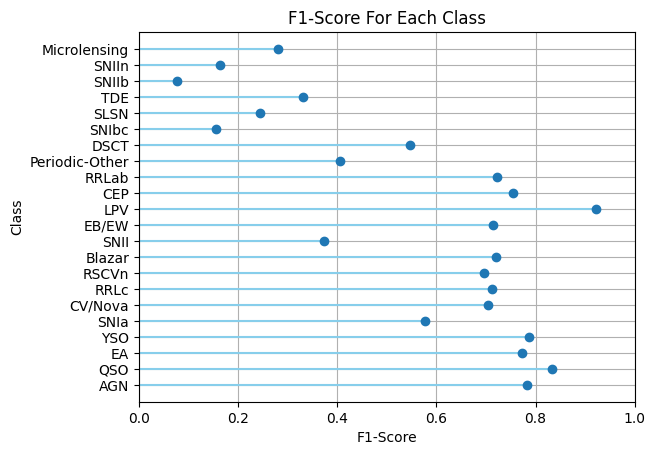

In [9]:
data_dict =  classification_report(target, results, target_names=list(dict.keys()),digits = 4, output_dict=True)
classes = data_dict.keys()
f1 = []
for key,value in data_dict.items():
    if key in dict.keys():
        print(key,value)
        f1.append(value['f1-score'])
print(f1)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
 
# Create a dataframe
df = pd.DataFrame({'group':dict.keys(), 'values':f1 })
 
# Reorder it based on the values
ordered_df = df#.sort_values(by='values')
my_range=range(1,len(df.index)+1)
 
# The horizontal plot is made using the hline function
plt.hlines(y=my_range, xmin=0, xmax=ordered_df['values'], color='skyblue')
plt.plot(ordered_df['values'].values, my_range, "o")
 
# Add titles and axis names
plt.yticks(my_range, ordered_df['group'])
plt.title("F1-Score For Each Class", loc='center')

plt.xlabel('F1-Score')
plt.ylabel('Class')
plt.xlim(0,1)

plt.grid('on')
# Show the plot
plt.show()

In [10]:
transient =  {
    "SNIa": 4,
    "SNII": 9,
    "SNIbc": 16,
    "SLSN": 17,
    "TDE": 18,
    "SNIIb": 19,
    "SNIIn": 20,
    "Microlensing": 21
}
stochastic =  {
    "AGN": 0,
    "QSO": 1,
    "YSO": 3,
    "CV/Nova": 5,
    "Blazar": 8,
}
periodic =  {
    "EA": 2,
    "RRLc": 6,
    "RSCVn": 7,
    "EB/EW": 10,
    "LPV": 11,
    "CEP": 12,
    "RRLab": 13,
    "Periodic-Other": 14,
    "DSCT": 15,
}

In [11]:
trans_f1 = []
stoch_f1 = []
per_f1 = []
for class_key, value in data_dict.items():
    #print(class_key)
    if class_key in dict.keys():
        
        if class_key in transient.keys():
            trans_f1.append(value['f1-score'])
        if class_key in stochastic.keys():
            stoch_f1.append(value['f1-score'])
        if class_key in periodic.keys():
            per_f1.append(value['f1-score'])
print('group eval:')
print('trans',np.mean(trans_f1))
print('stoch',np.mean(stoch_f1))

print('per',np.mean(per_f1))

group eval:
trans 0.2755024654260322
stoch 0.7652355680217524
per 0.6937624618150211


Normalized confusion matrix


<Axes: title={'center': ' FClassifier Results [TEST] \n\n  PRECISION : 0.547  RECALL : 0.605  F1-SCORE : 0.558  SUPPORT : 40698.000 '}, xlabel='Predicted label', ylabel='True label'>

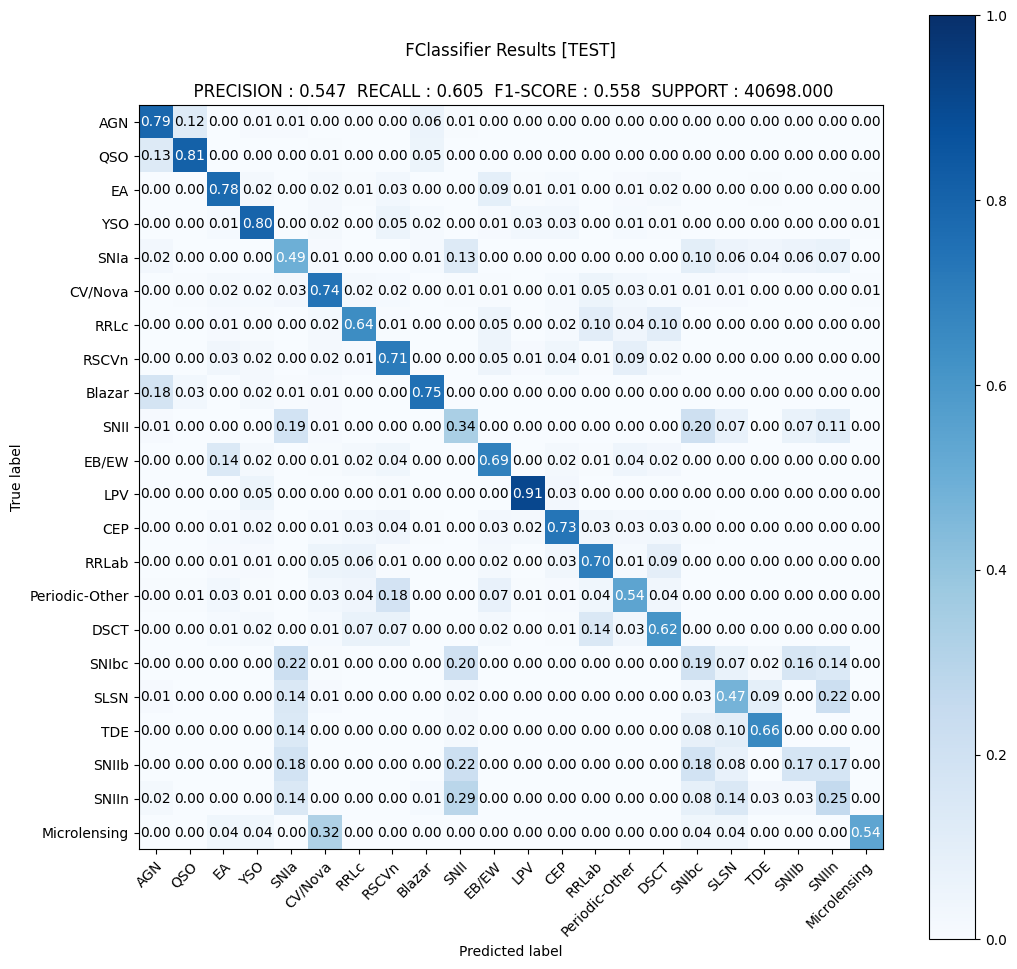

In [12]:
import matplotlib.pyplot as plt
from src.utils.plottinglib import elasticc_confusion_matrix
out_metrics_balto = classification_report(
    target, results, target_names=list(dict.keys()), output_dict=True
)["macro avg"]

template_balto = ""

for key in out_metrics_balto.keys():
    template_balto += " {} : {:.3f} ".format(key.upper(), out_metrics_balto[key])
fig, axes = plt.subplots(1, 1, figsize=(12, 12))
elasticc_confusion_matrix(
    y_true=np.array(target).astype(int),
    y_pred=np.array(results).astype(int),
    classes= np.array(list(dict.keys())),
    ax=axes,
    normalize=True,
    title=f" FClassifier Results [TEST] \n\n {template_balto}",
)